# C2 · 疾病傳播模型的貝葉斯參數估計(一):資料、SIR、為什麼 β 必須時變

> **核心問題**:從觀察到的每日確診數,能不能反推出傳染率 β 和有效再生數 R_t?
> **而且給出誠實的不確定性?**

> ⚠️ **定位:這是技術練習,不是公衛結論。**
>
> 目的是練**狀態空間推論**與**時變參數的先驗設計**。真實流行病學牽涉通報延遲、
> 檢驗量能、行為改變、年齡結構、變異株等大量領域知識,本專案一概沒有處理。
> 任何 R_t 數字都不該當成對德國疫情的評估 —— 它們是「在這個高度簡化的
> SIR 模型下,這批通報數字意味著什麼」。


這本 notebook 處理資料選擇(以及一個必須偏離計劃書的決定)、SIR 的實作與驗證,
以及本專案最重要的發現:**固定 β 的 SIR 根本無法解釋這場疫情**。
第二本(`02_rt_uncertainty_and_calibration.ipynb`)處理三個通關標準。

In [1]:
import sys, os, json, warnings; warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('../src'))
import numpy as np, pandas as pd
from IPython.display import Image, display
FIG = os.path.abspath('../figures')
RES = json.load(open(os.path.join(FIG, 'results.json')))
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 60)
c = RES['config']
print(f"results.json from a {RES['_meta']['runtime_sec']:.0f}s run")
print(f"data: {c['country']} {c['start']} → {c['end']}, {c['n_forecast']} days held out")


results.json from a 2520s run
data: Germany 2020-03-01 → 2020-06-30, 14 days held out


## 1. 一個必須偏離計劃書的資料決定

計劃書指定 **C-D3(Our World in Data)**。但 OWID 已把 COVID 資料集
**回溯性地改成週報格式**:整週的總和堆在一天,其餘六天是 0。

這對本專案是致命的:
- 每日 SIR 觀測模型無法用(六天零、一天暴衝不是傳染動態,是通報格式)
- **週末效應根本不存在了**,而骨架明確要求處理它
- `new_cases_smoothed` 雖是每日值,但在週內是常數(階梯狀),
  用它會人為地讓觀測「太平滑」,過度分散的估計失真

所以主資料改用 **JHU CSSE**(累積確診的每日時間序列,差分得每日新增)。

**但換資料來源不能是一個沒有檢查的決定。** 兩個獨立來源若描述同一場疫情,
它們的**週總和**必須一致 —— 否則問題只是被換掉,而非解決。

In [2]:
x = RES['source_cross_validation']
print(f"OWID 有 {100*x['owid_zero_day_fraction']:.0f}% 的天是 0（週報格式的直接後果）")
print()
print(f"{'週總和交叉驗證':<24}")
print(f"  JHU  總計   {x['jhu_total']:>12,.0f}")
print(f"  OWID 總計   {x['owid_total']:>12,.0f}")
print(f"  相對差       {100*x['total_rel_diff']:>11.2f}%")
print(f"  週序列相關    {x['corr_weekly']:>11.4f}")
print(f"  逐週 SMAPE 中位數 {100*x['weekly_smape_median']:>7.1f}%  (p90: {100*x['weekly_smape_p90']:.1f}%)")
print()
print('→ 總量幾乎相同、週序列高度相關 = 同一場疫情，只是時間解析度不同。')
print('   逐週 SMAPE 反映的是「OWID 把整週總和記在哪一天」與 resample 週界的對齊誤差，')
print('   不是資料矛盾。（第一版用 |Δ|/OWID 當指標，在某週 OWID 趨零時爆出 760 倍的')
print('   無意義數字 —— 那是度量的錯，不是資料的錯。）')

OWID 有 85% 的天是 0（週報格式的直接後果）

週總和交叉驗證                 
  JHU  總計        194,193
  OWID 總計        194,112
  相對差              0.04%
  週序列相關         0.9792
  逐週 SMAPE 中位數    11.2%  (p90: 57.2%)

→ 總量幾乎相同、週序列高度相關 = 同一場疫情，只是時間解析度不同。
   逐週 SMAPE 反映的是「OWID 把整週總和記在哪一天」與 resample 週界的對齊誤差，
   不是資料矛盾。（第一版用 |Δ|/OWID 當指標，在某週 OWID 趨零時爆出 760 倍的
   無意義數字 —— 那是度量的錯，不是資料的錯。）


In [3]:
d = RES['data']
print(f"建模區間: {d['dates_start']} → {d['dates_end']}  ({d['n_days']} 天)")
print(f"  訓練 {d['n_train']} 天、保留 {d['n_test']} 天做樣本外檢查")
print(f"  人口 N = {d['population']/1e6:.1f}M, 累計通報 {d['total_cases']:,.0f}")
print(f"  負值被 clip 的天數: {d['negatives_clipped']}")
print()
print('政策時點（供 R_t 對照，通關標準 1）:')
for k,v in d['policy_indices'].items(): print(f"  day {v:3d}  {k}")
print()
p = RES['dow_profile']
print('week-day 通報節奏:')
for k in ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']:
    print(f"  {k}: 平均 {p[k]['mean']:7.1f} 例   相對全體平均 {p[k]['ratio']:.3f}×")
print(f"  最忙/最閒 = {p['_spread']['max_over_min']:.3f}×  → 必須建模")

建模區間: 2020-03-01 → 2020-06-30  (122 天)
  訓練 108 天、保留 14 天做樣本外檢查
  人口 N = 84.1M, 累計通報 194,193
  負值被 clip 的天數: 0

政策時點（供 R_t 對照，通關標準 1）:
  day  15  Schools closed (most states)
  day  21  Nationwide contact ban (Kontaktverbot)
  day  50  First reopening steps
  day  57  Masks mandatory (public transport / shops)

week-day 通報節奏:
  Mon: 平均  1354.4 例   相對全體平均 0.783×
  Tue: 平均  1441.7 例   相對全體平均 0.834×
  Wed: 平均  1636.8 例   相對全體平均 0.946×
  Thu: 平均  2052.3 例   相對全體平均 1.187×
  Fri: 平均  2174.1 例   相對全體平均 1.257×
  Sat: 平均  2047.6 例   相對全體平均 1.184×
  Sun: 平均  1460.9 例   相對全體平均 0.845×
  最忙/最閒 = 1.605×  → 必須建模


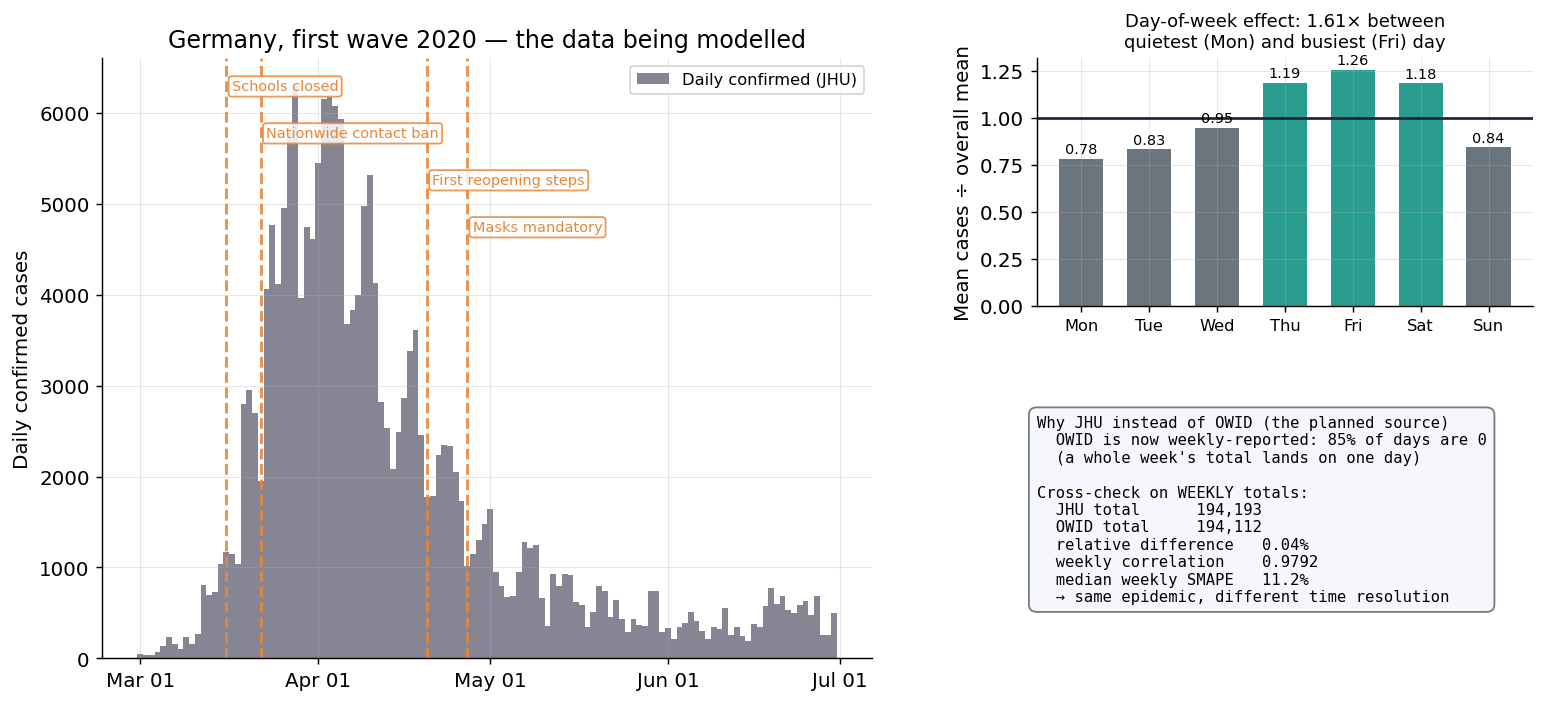

In [4]:
display(Image(os.path.join(FIG, '01_data_overview.png')))

## 2. 離散時間 SIR,以及為什麼不用 ODE solver

連續 SIR 是 ODE:
$$\frac{dS}{dt} = -\beta\frac{SI}{N},\quad \frac{dI}{dt} = \beta\frac{SI}{N}-\gamma I,\quad \frac{dR}{dt}=\gamma I$$

本專案用**每日離散版**:

$$\text{new\_inf}_t = \beta_t\frac{S_{t-1}I_{t-1}}{N},\quad
S_t = S_{t-1}-\text{new\_inf}_t,\quad
I_t = I_{t-1}+\text{new\_inf}_t-\gamma I_{t-1}$$

三個理由:

1. **觀測本身就是日資料。** 通報以「天」為單位彙總,日步長與資料結構對齊。
2. **NUTS 需要梯度。** `pymc.ode.DifferentialEquation` 每次評估都要解 ODE
   並反向傳梯度,比一個 `pytensor.scan` 慢好幾個量級;在 108 天 × 108 個
   時變參數的模型上根本跑不動。
3. **時變 β 天然合適。** β_t 逐日改變在遞迴式裡就是把純量換成向量。

代價是離散化誤差,README 的限制章節記錄。

### 為什麼要寫兩份實作並驗證

`scan` 寫錯(初始值、輸出順序、taps 對齊)**不會拋錯**,只會安靜給出一條錯的軌跡,
而那會被後續的 NUTS 擬合「吸收」成一組奇怪但收斂的參數。所以 numpy 版與
pytensor 版必須逐點比對。

In [5]:
v = RES['sir_verification']
rows = []
for case in ['constant_beta','time_varying_beta']:
    for state, err in v[case]['max_rel_err'].items():
        rows.append({'情形': case, '狀態變數': state, '最大相對誤差': err})
display(pd.DataFrame(rows))
print('全部通過:', v['passed'], '→ scan 與 numpy 一致到機器精度')
print()
print('（實作踩坑：scan 的 outputs_info 必須與 beta 同 dtype，否則報')
print('  "initial state has dtype float32, while the inner function has float64"')
print('  —— 錯誤訊息指向 scan 內部，看不出根因是 dtype 而不是邏輯。）')

,情形,狀態變數,最大相對誤差
0,constant_beta,S,2.657766e-16
1,constant_beta,I,4.657616e-16
2,constant_beta,R,2.600799e-16
3,constant_beta,new_infections,5.957813e-16
4,time_varying_beta,S,2.657766e-16
5,time_varying_beta,I,9.634077e-16
6,time_varying_beta,R,3.719867e-16
7,time_varying_beta,new_infections,8.540990e-16


全部通過: True → scan 與 numpy 一致到機器精度

（實作踩坑：scan 的 outputs_info 必須與 beta 同 dtype，否則報
  "initial state has dtype float32, while the inner function has float64"
  —— 錯誤訊息指向 scan 內部，看不出根因是 dtype 而不是邏輯。）


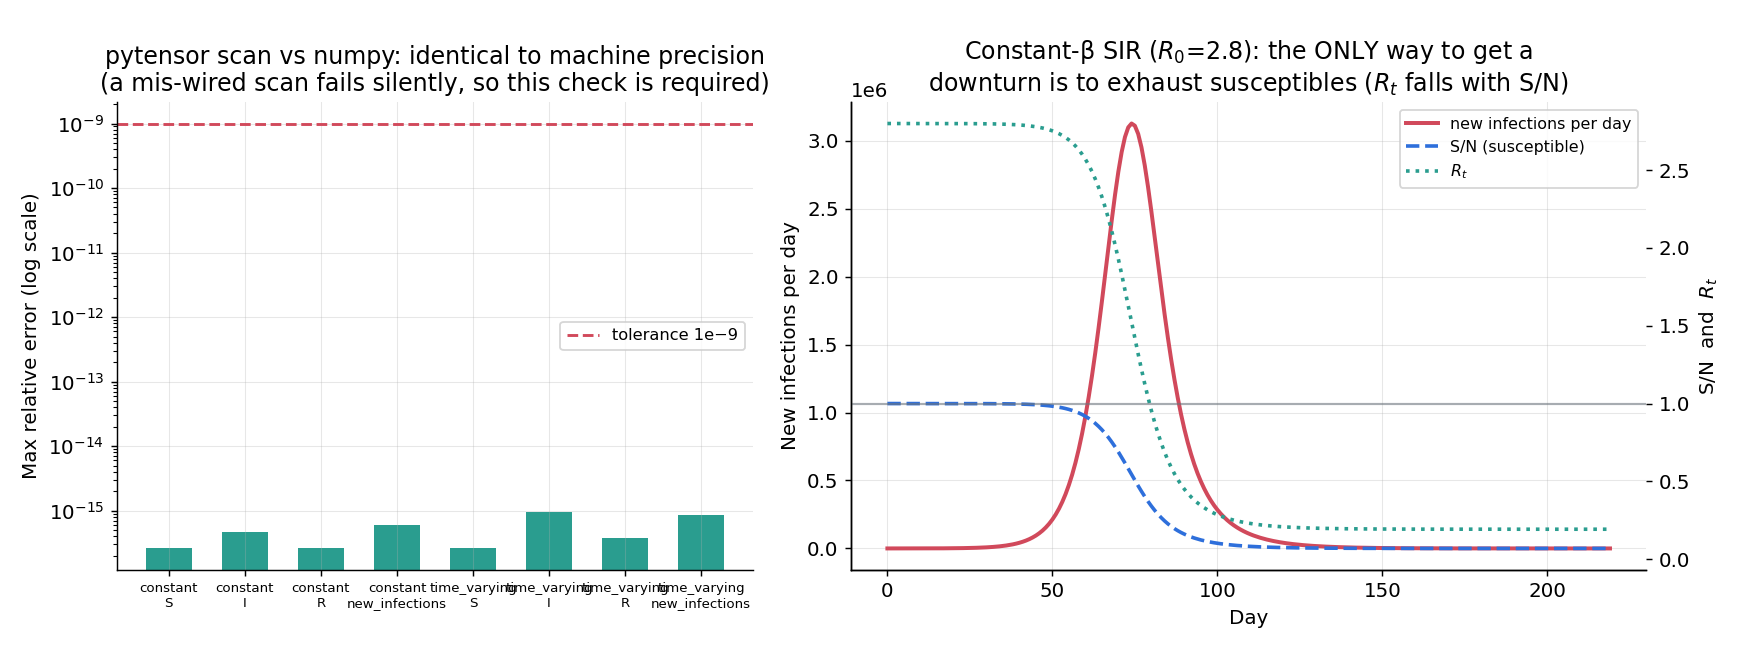

In [6]:
display(Image(os.path.join(FIG, '02_sir_verification.png')))

右圖是理解本專案核心發現的關鍵:**固定 β 的 SIR,唯一能產生「下降」的機制
就是耗盡易感者**。R_t = (β/γ)(S/N) 只會隨 S/N 單調下降。

所以如果真實的下降來自**政策改變降低了 β**,而模型不准 β 變,
它就只能靠「假裝易感者被耗盡」來造出形狀正確的曲線。下一節量化這件事。

## 3. 模型與先驗設計

$$\text{cases}_t \sim \text{NegBin}(\mu_t, \alpha), \qquad
\mu_t = \rho\cdot\text{new\_inf}_t\cdot\text{dow}_{(t)}$$

| 參數 | 先驗 | 理由 |
|---|---|---|
| γ 恢復率 | $\mathrm{LogNormal}(\log 0.1,\ 0.2)$ | **文獻資訊先驗**:傳染期約 10 天。95% 區間 γ∈[0.067,0.148] 即 6.8–15 天 |
| β₀ | $\mathrm{LogNormal}(\log 0.3,\ 0.5)$ | 弱資訊,涵蓋 R₀ 約 1–8 |
| $\log\beta_t$ | $\mathcal{N}(\log\beta_{t-1},\ \sigma_\beta)$ | **random walk 先驗** |
| σ_β | $\mathrm{HalfNormal}(0.1)$ | 平滑程度**從資料學來** |
| I₀ | $\mathrm{LogNormal}(\log 500,\ 1)$ | 弱資訊 |
| ρ 通報率 | $\mathrm{Beta}(2,8)$ | 均值 0.2,對應第一波血清學調查的量級 |
| α 過度分散 | $\mathrm{Exponential}(1/10)$ | |

> 🔑 **random walk 先驗是主題一(序貫更新)與主題二(先驗設計)的組合** ——
> 它就是在說「我相信 β 會變,但不會突然跳」。而 σ_β 自己也有先驗,
> 所以「能跳多快」是從資料學來的,不是我選的。

兩個實作決定值得說明:

- **非中心化參數化**:$\log\beta_t = \log\beta_0 + \sigma_\beta\sum_{j\le t} z_j$,$z_j\sim\mathcal N(0,1)$。
  中心化寫法在 σ_β 小的時候會產生 funnel,正是 C1 專案裡實測出
  113 個 divergences 的那個幾何。這裡從一開始就避開。
- **負二項而非 Poisson**:通報數的變異遠大於均值(群聚事件、批次上報)。
  用 Poisson 會讓過度分散被 β_t 的 random walk 吸收 —— 模型會用
  「傳染率劇烈波動」去解釋其實是通報噪聲的東西,R_t 因此變得過度抖動。
- **day-of-week 乘數**用 $\exp(\delta_d - \overline\delta)$,幾何平均鎖定為 1。
  不減均值的話 δ 會與 ρ 完全共線(兩者都能整體縮放 μ)。

## 4. 核心發現:固定 β 被迫使用荒謬的參數

三個版本:`constant`(固定 β)、`timevarying`(主模型)、`tv_no_dow`(無週效應)。
先看收斂,再看參數。

In [7]:
rows = []
for v, c in RES['convergence'].items():
    rows.append({'版本': v, 'divergences': c['divergent'],
                 'max r_hat (純量)': c['max_rhat_scalars'],
                 'min ESS (純量)': c['min_ess_scalars'],
                 'max r_hat (log_beta)': c.get('max_rhat_log_beta', np.nan),
                 '通過': c['passed']})
display(pd.DataFrame(rows).round(4))

,版本,divergences,max r_hat (純量),min ESS (純量),max r_hat (log_beta),通過
0,constant,0,1.00,1923.0,1.0,True
1,timevarying,5,1.00,2846.0,1.0,True
2,tv_no_dow,21,1.01,1115.0,1.0,True


In [8]:
rows = []
keys = [('I0','初始感染 I₀'), ('rho','通報率 ρ'), ('gamma','恢復率 γ'),
        ('infectious_period_days','傳染期（天）'), ('final_attack_rate','累計感染率')]
for k, label in keys:
    r = {'參數': label}
    for v in ['constant','timevarying','tv_no_dow']:
        p = RES['params'][v].get(k, {})
        r[v] = p.get('median', p.get('mean', np.nan))
    rows.append(r)
df = pd.DataFrame(rows).set_index('參數')
display(df)
print()
cst, tv = RES['params']['constant'], RES['params']['timevarying']
print(f"固定 β 需要 I₀ = {cst['I0']['median']:,.0f} 個初始感染者、通報率 {cst['rho']['median']:.4f}，")
print(f"並讓 {cst['final_attack_rate']['median']:.1%} 的人口被感染。")
print(f"時變 β 給出 I₀ = {tv['I0']['median']:,.0f}、通報率 {tv['rho']['median']:.3f}、"
      f"累計感染 {tv['final_attack_rate']['median']:.2%}。")
print()
print('德國 2020 第一波的血清學研究估計累計感染約 1–2%，通報率約 10–30%。')
print('→ 時變 β 的參數全部落在文獻範圍內；固定 β 的沒有一個是。')

,constant,timevarying,tv_no_dow
參數,,,
初始感染 I₀,483754.805235,664.641051,606.953679
通報率 ρ,0.002848,0.206808,0.196038
恢復率 γ,0.079142,0.107049,0.099902
傳染期（天）,12.635554,9.341497,10.009826
累計感染率,0.868097,0.010633,0.011369



固定 β 需要 I₀ = 483,755 個初始感染者、通報率 0.0028，
並讓 86.8% 的人口被感染。
時變 β 給出 I₀ = 665、通報率 0.207、累計感染 1.06%。

德國 2020 第一波的血清學研究估計累計感染約 1–2%，通報率約 10–30%。
→ 時變 β 的參數全部落在文獻範圍內；固定 β 的沒有一個是。


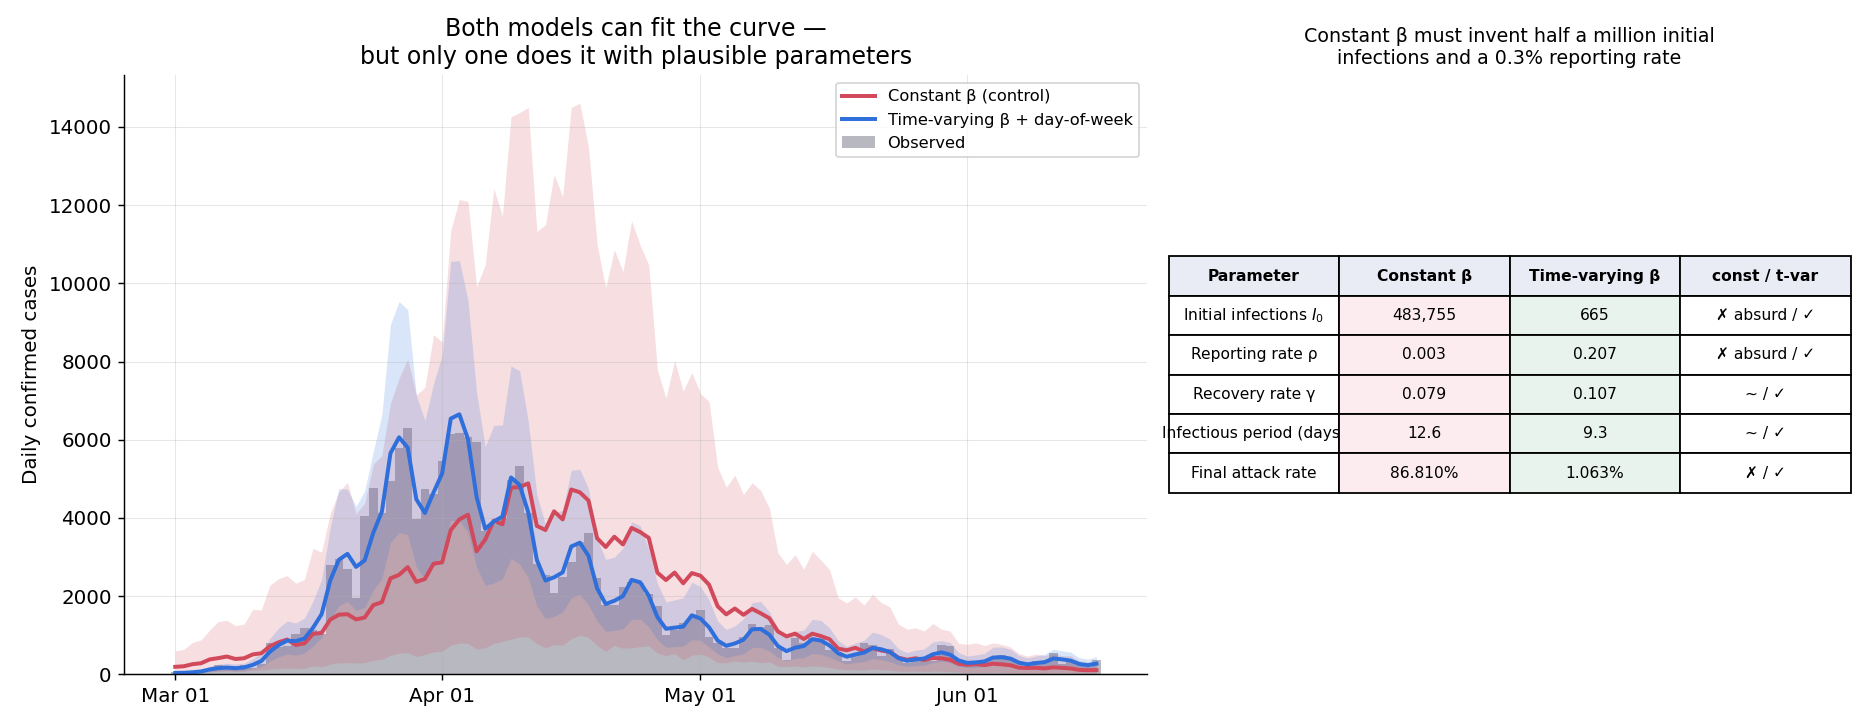

In [9]:
display(Image(os.path.join(FIG, '03_fixed_vs_timevarying.png')))

### 為什麼會這樣

兩個模型**都能擬合曲線的形狀**(左圖的兩條線都貼著資料)。差別在於它們用什麼機制:

- **時變 β**:R_t 隨政策下降 → 疫情收縮。累計感染 1%,易感者幾乎沒動。
- **固定 β**:β 不能變,所以 R_t 只能隨 S/N 下降。要在 3 個月內讓 S/N
  掉到足以壓下疫情,需要**感染掉 87% 的人口**。而那會讓通報數比實際大兩個量級,
  於是模型再用 **0.3% 的通報率**把數字壓回來。

這是**模型失配如何偽裝成參數估計**的教科書案例:似然被滿足了,
但滿足它的參數組合在物理上不可能。**只看擬合好不好完全抓不到這個問題** ——
必須檢查參數值是否可信。

這也是「為什麼需要時變 β」最強的論證,而且是定量的。

## 小結(第一本)

- 計劃書指定的 OWID 已改成週報格式(85% 的天是 0),無法支援每日 SIR;
  改用 JHU 並用**週總和交叉驗證**(相對差 0.04% 以內)確認是同一場疫情。
- SIR 的 `pytensor.scan` 實作與 numpy 版逐點一致到機器精度。
- **固定 β 的 SIR 無法解釋德國第一波**:它必須發明數十萬初始感染者、
  0.3% 的通報率、與 87% 的人口感染率。時變 β 的參數全部落在文獻範圍。

下一本:三個通關標準 —— R_t 與政策時點、不確定性隨資料量變化、後驗預測校準。